In [1]:
DATE = 'JUN11'
default_json  = '_json/default_params.json'
controller_mode = 'occupancy'

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

RC_SIMULATOR = "ETHlib"
if RC_SIMULATOR not in sys.path:
    sys.path.insert(0, RC_SIMULATOR)

from _ import *
from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system
case = RCCase(
    year=2023,
    loc_json              = Path("_json/location_params.json"),
    geo_json              = Path("_json/geo_params.json"),
    default_json          = Path("_json/default_params.json"),
    epw_path              = Path("../src/_base/epw/ED-TMYx.2023.epw"),
    occupancy_profile_csv = Path("ETHlib/auxiliary/schedules_el_OFFICE.csv"),
    Zone=Zone,
    supply_system=supply_system,
    emission_system=emission_system,
)
case.occupancy_profile = (
    pd.read_csv(Path("_data/bldg_LoD.csv"), usecols=["D"])
      .rename(columns={"D": "People"})
      .iloc[:8760]
      .reset_index(drop=True)
)

In [3]:
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
run_record_path = Path(f"_json/_run/{DATE}.json")
with open(run_record_path, "r", encoding="utf-8") as f:
    run_record = json.load(f)
uq_path = Path(run_record["latest_uq_json"])
print(uq_path)

_json/UC/uc__20260614_001.json


In [4]:
##
def run_oat_from_uq_json(
    uq_json_path,
    default_params,
    controller_mode="occupancy",
    save_dir=None,
    period_start="2023-01-20",
    period_end="2023-03-20",
):

    uq_json_path = Path(uq_json_path)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(uq_json_path, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    oat_results = {}
    oat_euis = {}

    def calc_period_eui(res):
        res_period = res.loc[period_start:period_end]

        heating = res_period["HeatingEnergy"].sum()
        cooling = res_period["CoolingEnergy"].sum()

        return {
            "HeatingEnergy": heating,
            "CoolingEnergy": cooling,
        }

    summary_rows = []

    n_runs = 1 + 2 * len(uq_config["parameters"])

    with show_progress(
        range(n_runs),
        total=n_runs,
        desc="Running OAT",
        unit="case",
    ) as pbar:

        # Baseline run
        baseline_params = default_params.copy()

        oat_results["baseline"], _, _ = run_model_case(
            case=case,
            sampled_params=baseline_params,
            controller_mode=controller_mode,
        )

        pbar.update(1)

        oat_euis["baseline"] = calc_period_eui(oat_results["baseline"])

        baseline_heating = oat_euis["baseline"]["HeatingEnergy"]
        baseline_cooling = oat_euis["baseline"]["CoolingEnergy"]
        baseline_total = baseline_heating + baseline_cooling

        summary_rows.append({
            "parameter": "baseline",
            "case": "baseline",
            "value": None,
            "heating_eui": baseline_heating,
            "cooling_eui": baseline_cooling,
            "total_hvac_eui": baseline_total,
            "delta_heating_eui": 0.0,
            "delta_cooling_eui": 0.0,
            "delta_total_hvac_eui": 0.0,
        })

        # OAT runs
        for param_name, param_config in uq_config["parameters"].items():

            for bound_name in ["lower", "upper"]:

                sampled_params = default_params.copy()
                sampled_params[param_name] = param_config[bound_name]

                case_name = f"OAT_{param_name}_{bound_name}"

                oat_results[case_name], _, _ = run_model_case(
                    case=case,
                    sampled_params=sampled_params,
                    controller_mode=controller_mode,
                )

                pbar.update(1)

                oat_euis[case_name] = calc_period_eui(oat_results[case_name])

                heating_eui = oat_euis[case_name]["HeatingEnergy"]
                cooling_eui = oat_euis[case_name]["CoolingEnergy"]
                total_hvac_eui = heating_eui + cooling_eui

                summary_rows.append({
                    "parameter": param_name,
                    "case": bound_name,
                    "value": param_config[bound_name],
                    "heating_eui": heating_eui,
                    "cooling_eui": cooling_eui,
                    "total_hvac_eui": total_hvac_eui,
                    "delta_heating_eui": heating_eui - baseline_heating,
                    "delta_cooling_eui": cooling_eui - baseline_cooling,
                    "delta_total_hvac_eui": total_hvac_eui - baseline_total,
                })

    oat_summary = pd.DataFrame(summary_rows)

    output_path = save_dir / f"oat_summary_{period_start}_to_{period_end}.csv"
    oat_summary.to_csv(output_path, index=False)

    print(f"OAT summary saved to: {output_path}")

    return oat_results, oat_euis, oat_summary

# Case

In [5]:
start = "2023-01-22 00:00"
end   = "2023-03-17 23:00"

In [6]:
uq_json_path = Path(uq_path)
save_dir = Path(f"_json/_run/{DATE}")
save_dir.mkdir(parents=True, exist_ok=True)

oat_results, oat_euis, oat_summary = run_oat_from_uq_json(
    uq_json_path,
    DEFAULT_PARAMS,
    save_dir = save_dir,
    controller_mode=controller_mode,
    period_start=start,
    period_end=end,
)

Running OAT:   0%|          | 0/41 [00:00<?, ?case/s]

OAT summary saved to: _json/_run/JUN11/oat_summary_2023-01-22 00:00_to_2023-03-17 23:00.csv


# Visualisation

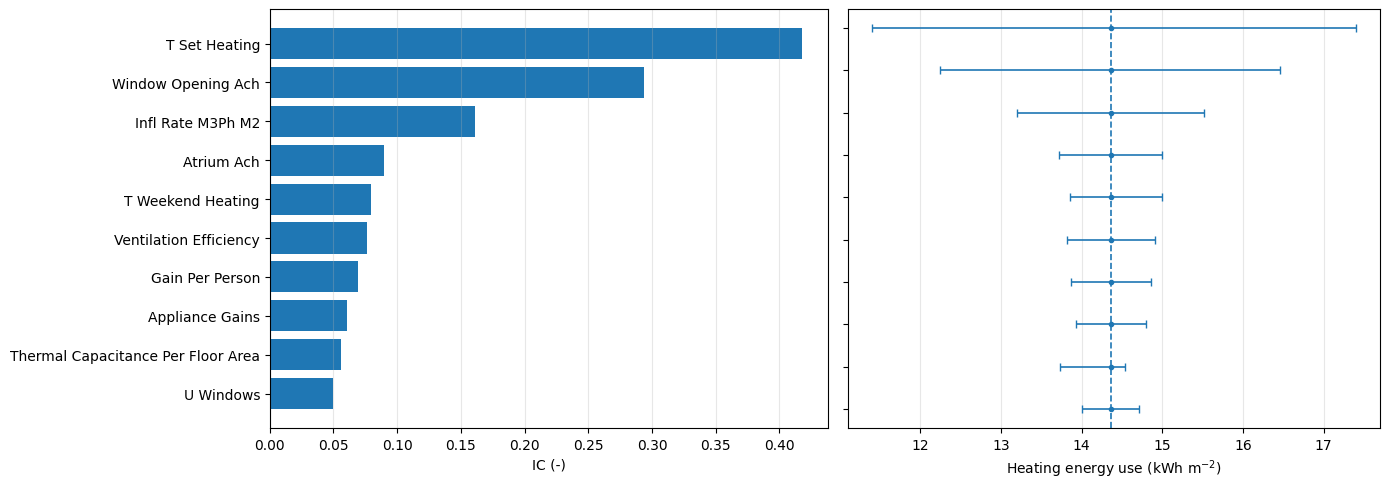

In [7]:
def plot_oat_summary(
    oat_summary,
    metric="heating_eui",
    reference_value=None,
    top_n=10,
    param_labels=None
):
    df = oat_summary.copy()

    if param_labels is None:
        param_labels = {}

    baseline_row = df[df["case"] == "baseline"]
    if baseline_row.empty:
        raise ValueError("No baseline row found. Expected case == 'baseline'.")

    baseline_value = baseline_row[metric].iloc[0]
    df_var = df[df["case"].isin(["lower", "upper"])].copy()

    pivot = df_var.pivot_table(
        index="parameter",
        columns="case",
        values=metric,
        aggfunc="first"
    )

    pivot = pivot.dropna(subset=["lower", "upper"]).copy()

    pivot["min_val"] = pivot[["lower", "upper"]].min(axis=1)
    pivot["max_val"] = pivot[["lower", "upper"]].max(axis=1)
    pivot["IC"] = (pivot["max_val"] - pivot["min_val"]) / baseline_value

    pivot["label"] = [
        param_labels.get(p, p.replace("_", " ").title())
        for p in pivot.index
    ]

    plot_df = pivot.sort_values("IC", ascending=False).head(top_n).copy()
    plot_df = plot_df.iloc[::-1]
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(14, 5),
        gridspec_kw={"width_ratios": [1.05, 1.0]}
    )

    y = np.arange(len(plot_df))
    ax1.barh(y, plot_df["IC"])
    ax1.set_yticks(y)
    ax1.set_yticklabels(plot_df["label"])
    ax1.set_xlabel("IC (-)")
    ax1.grid(True, axis="x", alpha=0.3)
    xmin = np.minimum(plot_df["min_val"], baseline_value)
    xmax = np.maximum(plot_df["max_val"], baseline_value)

    xerr_left = baseline_value - xmin
    xerr_right = xmax - baseline_value

    ax2.errorbar(
        x=np.full(len(plot_df), baseline_value),
        y=y,
        xerr=[xerr_left, xerr_right],
        fmt="o",
        capsize=3,
        linewidth=1.2,
        markersize=3,
    )

    ax2.set_yticks(y)
    ax2.set_yticklabels([])
    ax2.set_xlabel(r"Heating energy use (kWh m$^{-2}$)")
    ax2.grid(True, axis="x", alpha=0.3)

    if reference_value is None:
        reference_value = baseline_value

    ax2.axvline(reference_value, linestyle="--", linewidth=1.2)

    plt.tight_layout()
    plt.show()

    return plot_df

plot_df = plot_oat_summary(
    oat_summary=oat_summary,
    metric="heating_eui",
    reference_value=None,
    top_n=10,
    param_labels=None
)

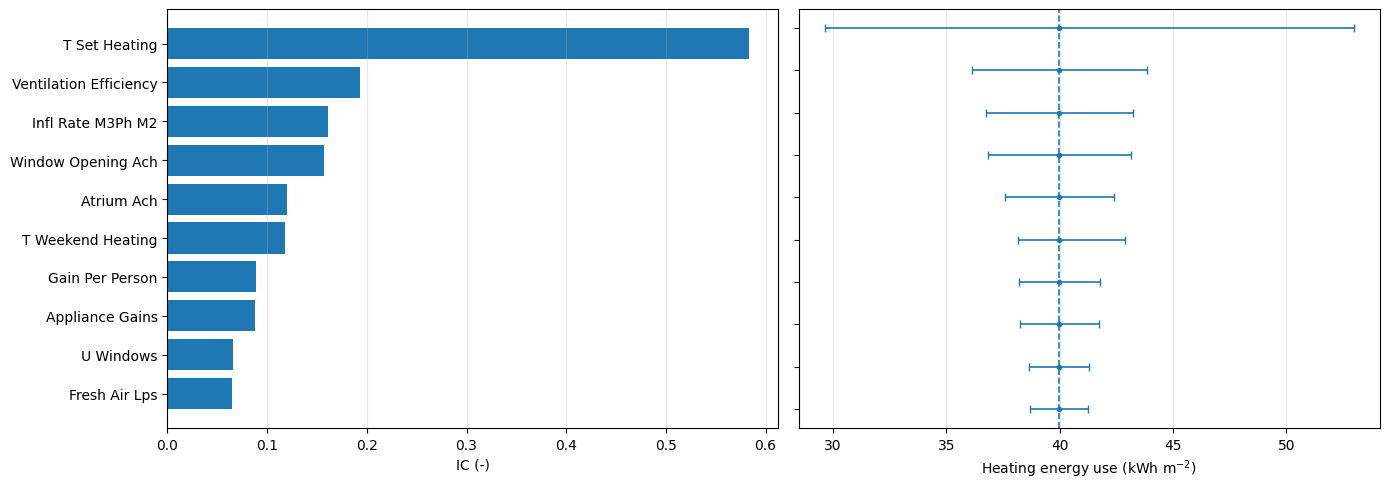

In [8]:
def save_top_oat_params_as_uq_json(
    plot_df,
    source_uq_json,
    save_dir,
    output_filename="OAT.json",
    top_n=4,
):
    source_uq_json = Path(source_uq_json)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    output_path = save_dir / output_filename

    with open(source_uq_json, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    top_params = (
        plot_df
        .sort_values("IC", ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    top_config = {
        "N": uq_config["N"],
        "seed": uq_config["seed"],
        "parameters": {}
    }

    for param in top_params:
        if param not in uq_config["parameters"]:
            raise KeyError(
                f"Parameter '{param}' from plot_df was not found in {source_uq_json}"
            )

        top_config["parameters"][param] = uq_config["parameters"][param]

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(top_config, f, indent=2)

    print(f"Saved top-{top_n} OAT UQ JSON to: {output_path}")

    return top_config, output_path

top4_uq_config, top4_uq_path = save_top_oat_params_as_uq_json(
    plot_df=plot_df,
    source_uq_json=Path(uq_path),
    save_dir=save_dir,
    output_filename="OAT.json",
    top_n=4,
)

Saved top-4 OAT UQ JSON to: _json/_run/JUN11/OAT.json
